In [ ]:
!pip install wget

# Linear Regression

In [2]:
import copy
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(cmap.N)]

mpl.rcParams["font.size"] = 24
mpl.rcParams["lines.linewidth"] = 2


## Load Dataset and Prepare Data

In [3]:
!python -m wget https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv \
    --output delaney-processed.csv


Saved under delaney-processed.csv


In [4]:
DELANEY_FILE = "delaney-processed.csv"
df = pd.read_csv(DELANEY_FILE)
print(f"Number of molecules in the dataset: {df.shape[0]}")

Number of molecules in the dataset: 1128


### logS vs. Molecular Weight

In [5]:
# features
X = df[["Molecular Weight"]].values
X = X.reshape(-1, 1)
X = np.hstack([np.ones_like(X), X])

# ground truth
Y = df["measured log solubility in mols per litre"].values
Y = Y.reshape(-1, 1)

In [6]:
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

Shape of X: (1128, 2)
Shape of Y: (1128, 1)


Text(0, 0.5, 'log solubility (mol/L)')

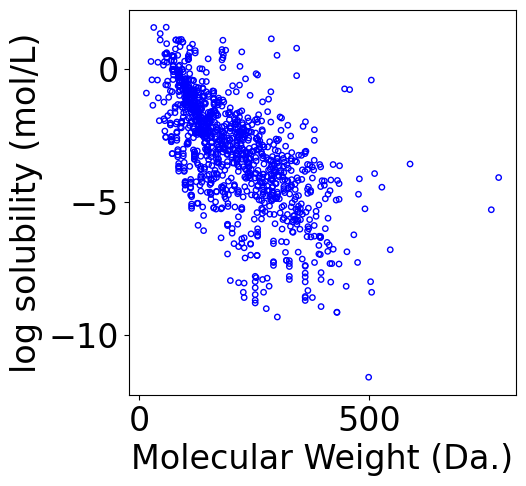

In [7]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
# scatter

ax.scatter(X[:, -1], Y.reshape(-1), \
            s=15, marker='o', \
            facecolors='none', edgecolor="blue")

ax.set_xlabel("Molecular Weight (Da.)")
ax.set_ylabel("log solubility (mol/L)")

## Analytical solution

In [8]:
theta = np.linalg.inv((X.T @ X)) @ (X.T @ Y)

In [9]:
theta

array([[-0.38596872],
       [-0.01306351]])

### Loss

In [10]:
y_pred = X @ theta
loss = np.mean((y_pred - Y)**2)
print(f"Loss: {loss}")

Loss: 2.5914815319019286


### Plot Correlation

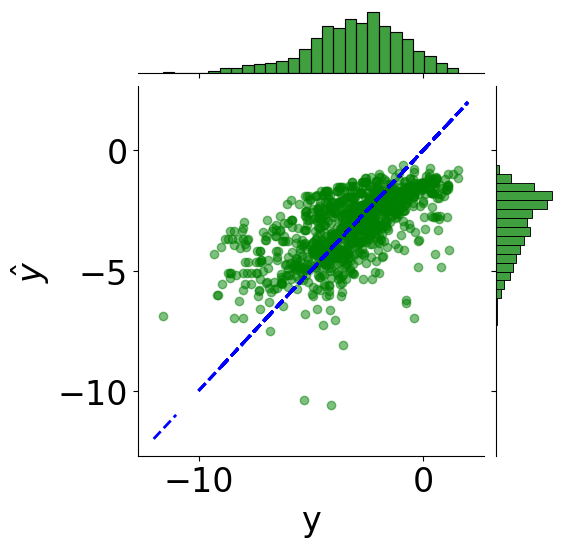

In [11]:
min_logS = np.min(Y)
max_logS = np.max(Y)
x_line = np.linspace(np.floor(min_logS), np.ceil(max_logS), 100)

tmp_df = pd.DataFrame({"y": Y.reshape(-1), r"$\hat{y}$": y_pred.reshape(-1)})

# scatter plot
g = sns.JointGrid(x="y", y=r"$\hat{y}$", data=tmp_df)
g = g.plot_joint(plt.scatter, c="green", alpha=0.5)

# line: y_pred = y
y_line = np.linspace(np.floor(Y.reshape(-1)), np.ceil(Y.reshape(-1)), 200)
g.ax_joint.plot(y_line, y_line, color="blue", linestyle="--");

# histograms
g = g.plot_marginals(sns.histplot, data=df, color="green", kde=False)

In [12]:
from sklearn.metrics import r2_score
print(f"Coefficient of determination: {r2_score(Y.reshape(-1), y_pred):.2f}")

Coefficient of determination: 0.41


### Plot the regression line

Text(-6.152777777777777, 0.5, 'log solubility (mol/L)')

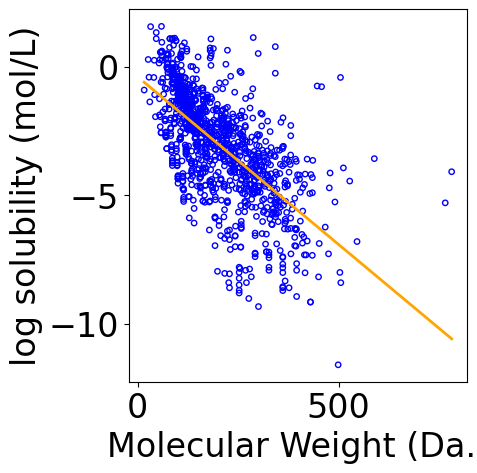

In [13]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

plt.tight_layout()
ax.scatter(X[:, -1], Y.reshape(-1), \
            s=15, marker='o', \
            facecolors='none', edgecolor="blue")

min_X = np.min(X[:, -1])
max_X = np.max(X[:, -1])
x_line = np.linspace(np.floor(min_X), np.ceil(max_X), 100)
x_line = x_line.reshape(-1, 1)
x_line = np.hstack([np.ones_like(x_line), x_line])
y_pred_line = x_line @ theta

line, = ax.plot(x_line[:, -1], y_pred_line, color="orange", label="Fitted line")

ax.set_xlabel("Molecular Weight (Da.)")
ax.set_ylabel("log solubility (mol/L)")

## Gradient Descent

In [14]:
lr = 1e-6

theta_list = []
loss_list = []
# theta = np.random.randn(2, 1).reshape(-1, 1)
theta = np.array([0, 0]).reshape(-1, 1)
n_epochs = 100

for _ in range(n_epochs):
    theta_list.append(copy.deepcopy(theta))
    y_pred = X @ theta
    loss = np.mean((y_pred - Y).reshape(-1)**2)
    loss_list.append(loss)
    grad = 2*X.T @ (X @ theta - Y) / Y.shape[0]
    theta = theta - lr * grad

In [15]:
print("Final loss:", loss_list[-1])

Final loss: 2.6216033000052184


Text(0, 0.5, 'Loss')

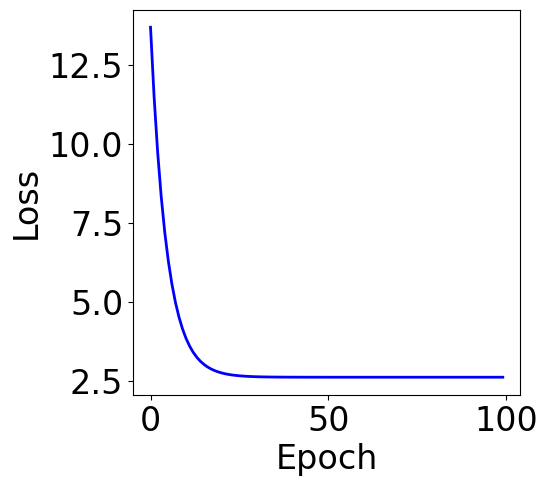

In [16]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(loss_list, c="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")

### Plot Iterative Process

/tmp/ipython-input-17-4040914613.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend(loc="upper right")


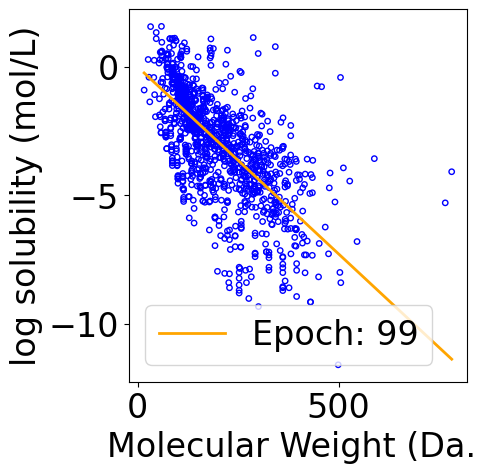

In [17]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))

plt.tight_layout()
ax.scatter(X[:, -1], Y.reshape(-1), \
            s=15, marker='o', \
            facecolors='none', edgecolor="blue")

min_X = np.min(X[:, -1])
max_X = np.max(X[:, -1])
x_line = np.linspace(np.floor(min_X), np.ceil(max_X), 100)
x_line = x_line.reshape(-1, 1)
x_line = np.hstack([np.ones_like(x_line), x_line])

line, = ax.plot([], [], color="orange", label="")

ax.set_xlabel("Molecular Weight (Da.)")
ax.set_ylabel("log solubility (mol/L)")

legend = plt.legend(loc="upper right")

def animate(i):
    y_pred_line = x_line @ theta_list[i]
    line.set_data(x_line[:, -1], y_pred_line)
    line.set_label(f"Epoch: {i}")
    legend = plt.legend()
    return line, legend


ani = animation.FuncAnimation(f, animate, repeat=True, frames=len(theta_list), interval=100, blit=True)

writer = animation.PillowWriter(fps=10,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save("theta_iteration.gif", writer=writer)

## Data Normalization in Gradient Descent

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
norm_mw = scaler.fit_transform(df[["Molecular Weight"]].values)
X = np.hstack([np.ones_like(norm_mw), norm_mw])

In [19]:
lr = 1e-1

theta_list = []
loss_list = []
# theta = np.random.randn(2, 1).reshape(-1, 1)
theta = np.array([0, 0]).reshape(-1, 1)
n_epochs = 20

for _ in range(n_epochs):
    theta_list.append(copy.deepcopy(theta))
    y_pred = X @ theta
    loss = np.mean((y_pred - Y).reshape(-1)**2)
    loss_list.append(loss)
    grad = 2*X.T @ (X @ theta - Y) / Y.shape[0]
    theta = theta - lr * grad

In [20]:
print("Final loss:", loss_list[-1])

Final loss: 2.593787495277282


### Plot Training Curve

Text(0, 0.5, 'Loss')

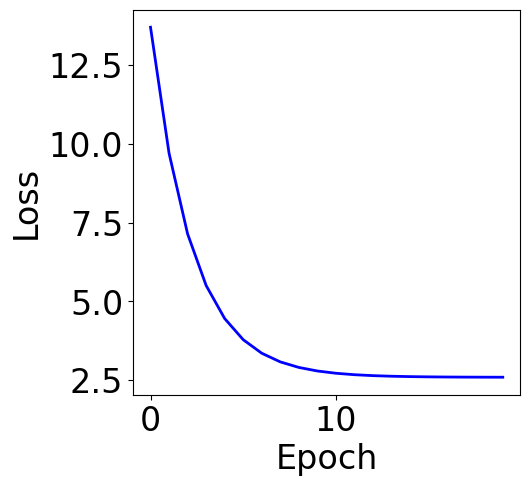

In [21]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(loss_list, c="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")

### Parameter Contour

In [22]:
def V(xx, yy):
    losses = []
    theta = np.hstack([xx.reshape(-1, 1), yy.reshape(-1, 1)])
    for i in range(theta.shape[0]):
        y_pred = X @ theta[i].reshape(-1, 1)
        loss = np.mean((y_pred - Y).reshape(-1)**2)
        losses.append(loss)
    return np.array(losses)

# calculate contour
t1 = np.arange(-6, 2, 1e-1)
t2 = np.arange(-4, 4, 1e-1)
xx, yy = np.meshgrid(t1, t2)
z = V(xx.ravel(), yy.ravel()).reshape(len(t2), -1)

Text(0, 0.5, '$\\theta_1$')

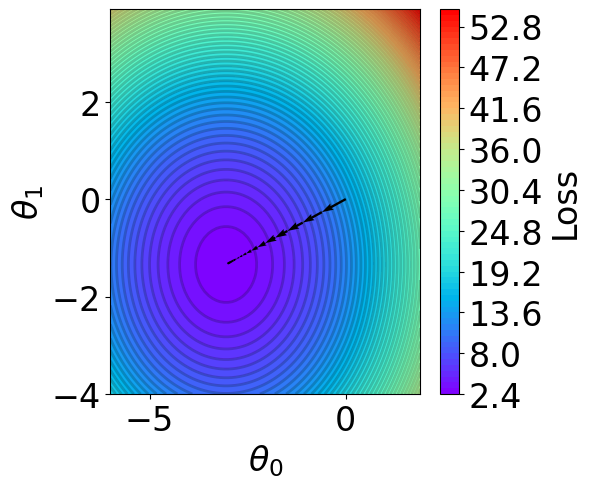

In [23]:
fig,ax = plt.subplots(1,1,figsize=(5,5))

n_levels = 75
c = ax.contourf(t1, t2, z, cmap='rainbow', levels=n_levels, zorder=1)
ax.contour(t1,t2, z, levels=n_levels, zorder=1, colors='black', alpha=0.2)
cb = fig.colorbar(c)
cb.set_label("Loss")

r=0.1
g=0.1
b=0.2
ax.patch.set_facecolor((r,g,b,.15))


# plot trajectory
for i in range(len(theta_list)-1):
    plt.quiver(theta_list[i][0], theta_list[i][1], # from point
               theta_list[i+1][0]-theta_list[i][0],  theta_list[i+1][1]-theta_list[i][1], # to point:
               angles="xy", scale_units="xy", scale=1, color="black",
               linewidth=1.5)


ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')

## Stochastic Gradient Descent and Mini-batching

In [24]:
lr = 1e-1

theta_list = []
loss_list = []
theta = np.array([0, 0]).reshape(-1, 1)
n_epochs = 100
batch_size = 32 # change the batch size here

for _ in range(n_epochs):
    indices = np.random.choice(X.shape[0], batch_size, replace=False)
    theta_list.append(copy.deepcopy(theta))
    y_pred = X[indices, :] @ theta
    y_true = Y[indices]
    loss = np.mean((y_pred - y_true).reshape(-1)**2)
    loss_list.append(loss)
    grad = 2*X[indices, :].T @ (y_pred - y_true) / len(indices)
    theta = theta - lr * grad

In [25]:
print("Final loss:", pd.Series(loss_list).rolling(5).mean().iloc[-1])

Final loss: 2.526345974117258


### Plot Training CUrve

Text(0, 0.5, 'Loss')

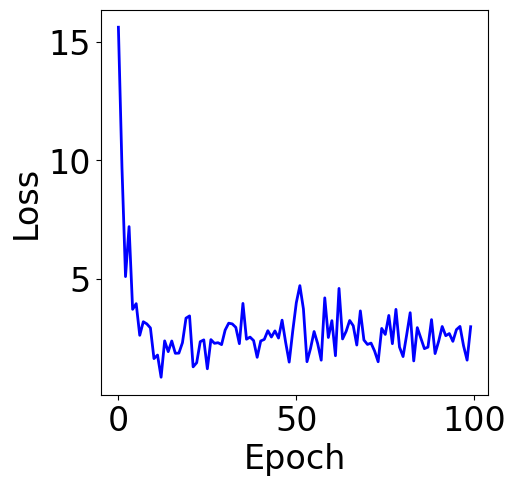

In [26]:
f, ax = plt.subplots(1, 1, figsize=(5,5))

ax.plot(loss_list, c="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")

### Parameter Contour

In [27]:
def V(xx, yy):
    losses = []
    theta = np.hstack([xx.reshape(-1, 1), yy.reshape(-1, 1)])
    for i in range(theta.shape[0]):
        y_pred = X @ theta[i].reshape(-1, 1)
        loss = np.mean((y_pred - Y).reshape(-1)**2)
        losses.append(loss)
    return np.array(losses)

# calculate contour
region = np.stack(theta_list)

t1 = np.arange(-6, 2, 1e-1)
t2 = np.arange(-4, 4, 1e-1)
xx, yy = np.meshgrid(t1, t2)
z = V(xx.ravel(), yy.ravel()).reshape(len(t2), -1)

Text(0, 0.5, '$\\theta_1$')

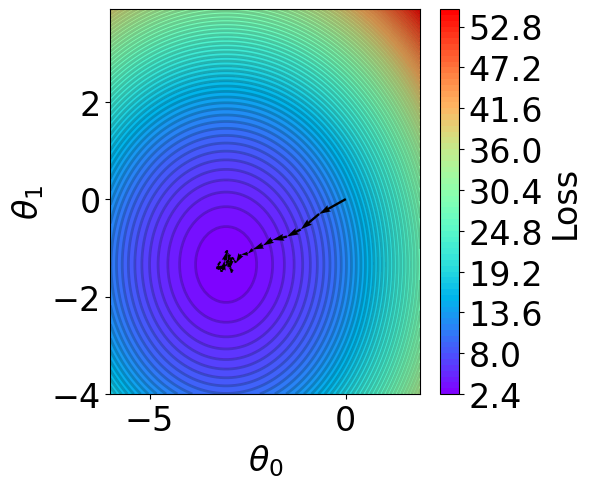

In [28]:
fig,ax = plt.subplots(1,1,figsize=(5,5))

# z = np.ma.masked_greater(z, 10)
n_levels = 75
c = ax.contourf(t1, t2, z, cmap='rainbow', levels=n_levels, zorder=1)
ax.contour(t1,t2, z, levels=n_levels, zorder=1, colors='black', alpha=0.2)
cb = fig.colorbar(c)
cb.set_label("Loss")

r=0.1
g=0.1
b=0.2
ax.patch.set_facecolor((r,g,b,.15))


# plot trajectory

for i in range(50):
    plt.quiver(theta_list[i][0], theta_list[i][1], # from point
               theta_list[i+1][0]-theta_list[i][0],  theta_list[i+1][1]-theta_list[i][1], # to point:
               angles="xy", scale_units="xy", scale=1, color="black",
               linewidth=1.5)


ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')